# **Portfolio Descriptive Statistics**

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import os

import duckdb as dd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import *

In [17]:
con = dd.connect()

INPUT_PATH = Path(PROCESSED_DATA_DIR).as_posix()
INPUT_PATH_STR = f"{INPUT_PATH}/{MRD}"
print(INPUT_PATH_STR)

C:/Users/mario/Documents/GitHub Repos/guides/data/processed/mrd.parquet


In [4]:
os.getcwd()
os.chdir("images")

## **Latest Key Metrics by Arrears Stage**

The table below shows an overview of the performing vs non-performing book as of the latest date (December 2014). There are approximately 48k performing accounts with total credit card balances of ฿5.8 billion.

In [4]:
query = f"""
    WITH latest_date AS (
        SELECT MAX(CALENDAR_DATE) AS MAX_DATE
        FROM '{INPUT_PATH_STR}'
    )
    SELECT 
        ARREARS_STAGE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        ROUND(SUM(AMT_BALANCE), 0) AS TOTAL_BALANCE,
        ROUND(AVG(AMT_CREDIT_LIMIT_ACTUAL), 0) AS AVG_CREDIT_LIMIT,
        ROUND(AVG(AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL), 2) AS AVG_UTILISATION
    FROM '{INPUT_PATH_STR}'
    WHERE CALENDAR_DATE = (SELECT MAX_DATE FROM latest_date)
    GROUP BY ARREARS_STAGE
    ORDER BY ARREARS_STAGE;
"""
con.sql(query)

┌───────────────┬──────────────┬───────────────┬──────────────────┬─────────────────┐
│ ARREARS_STAGE │ TOTAL_VOLUME │ TOTAL_BALANCE │ AVG_CREDIT_LIMIT │ AVG_UTILISATION │
│    varchar    │    int64     │    double     │      double      │     double      │
├───────────────┼──────────────┼───────────────┼──────────────────┼─────────────────┤
│ 1. PERFORMING │        43998 │  4834698375.0 │         225306.0 │             0.4 │
│ 2. 1-30 DPD   │         2506 │   497715668.0 │         266078.0 │            0.78 │
│ 3. 31-90 DPD  │         1050 │   250621593.0 │         299271.0 │            0.83 │
│ 4. 90+ DPD    │         1333 │   336189251.0 │         300953.0 │            0.79 │
└───────────────┴──────────────┴───────────────┴──────────────────┴─────────────────┘

In [5]:
query = f"""
    SELECT MAX(CALENDAR_DATE) AS MAX_DATE
    FROM '{INPUT_PATH_STR}';
"""
con.sql(query)

┌────────────┐
│  MAX_DATE  │
│    date    │
├────────────┤
│ 2012-12-01 │
└────────────┘

## **Historical Key Metrics Overall**

The figures below show the historical volume, balance and credit limit for the whole portfolio. 


In [65]:
query = f"""
    SELECT 
        CALENDAR_DATE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        ROUND(SUM(AMT_BALANCE), 0) AS TOTAL_BALANCE,
        ROUND(AVG(AMT_CREDIT_LIMIT_ACTUAL), 0) AS AVG_CREDIT_LIMIT,
        ROUND(AVG(AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL), 2)*100 AS AVG_UTILISATION,
        SUM("12M_DEFAULT_OUTCOME")/COUNT(DISTINCT SK_ID_PREV)*100 AS "PORTFOLIO_LEVEL_12M_ODR",
        SUM(TRANSACTOR_INDICATOR)/COUNT(DISTINCT SK_ID_PREV)*100 AS TRANSACTOR_RATE,
        SUM(INACTIVE_INDICATOR)/COUNT(DISTINCT SK_ID_PREV)*100 AS INACTIVE_RATE
    FROM '{INPUT_PATH_STR}'
    GROUP BY CALENDAR_DATE
    ORDER BY CALENDAR_DATE ASC;
"""
df = con.sql(query).df()

### **Total Volume**

C:\Users\mario\AppData\Local\Temp\ipykernel_38200\2773393181.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


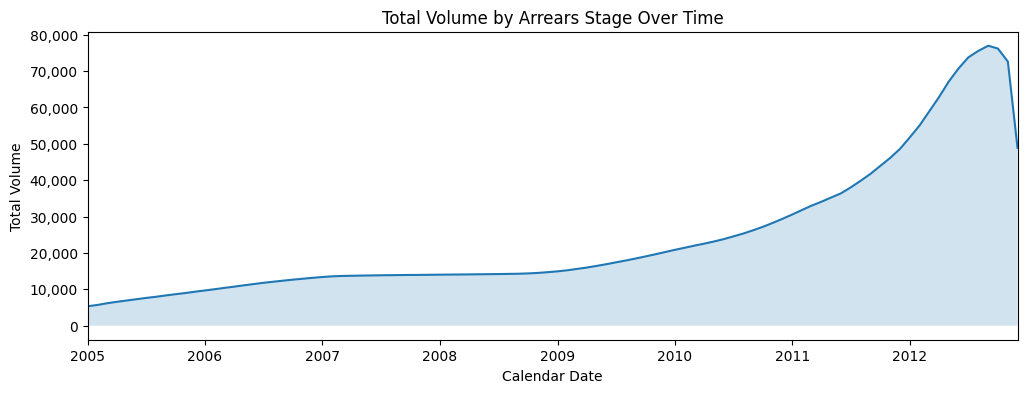

In [66]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="TOTAL_VOLUME")
plt.fill_between(df.CALENDAR_DATE.values, df.TOTAL_VOLUME.values, alpha=0.2)
plt.title("Total Volume by Arrears Stage Over Time")
plt.ylabel("Total Volume")
plt.xlabel("Calendar Date")
plt.xlim(df.CALENDAR_DATE.min(), df.CALENDAR_DATE.max())

ticks = plt.gca().get_yticks()
ylabels = ["{:,.0f}".format(y) for y in ticks]
plt.gca().set_yticklabels(ylabels)

plt.show()

### **Total Volume**

C:\Users\mario\AppData\Local\Temp\ipykernel_38200\3931450134.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


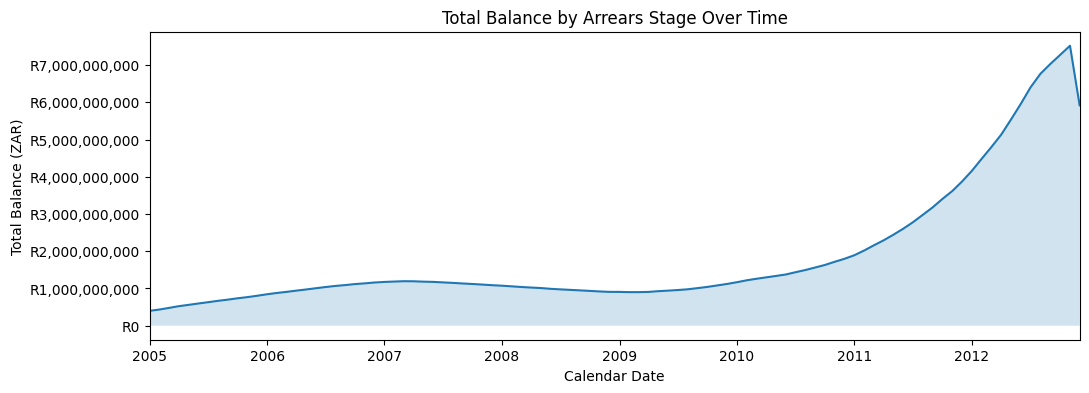

In [ ]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="TOTAL_BALANCE")
plt.fill_between(df.CALENDAR_DATE.values, df.TOTAL_BALANCE.values, alpha=0.2)
plt.title("Total Balance by Arrears Stage Over Time")
plt.ylabel("Total Balance (ZAR)")
plt.xlabel("Calendar Date")
plt.xlim(df.CALENDAR_DATE.min(), df.CALENDAR_DATE.max())

ticks = plt.gca().get_yticks()
ylabels = ["R" + "{:,.0f}".format(y) for y in ticks]
plt.gca().set_yticklabels(ylabels)

plt.show()

### **Average Credit Limit**

C:\Users\mario\AppData\Local\Temp\ipykernel_38200\2804900869.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


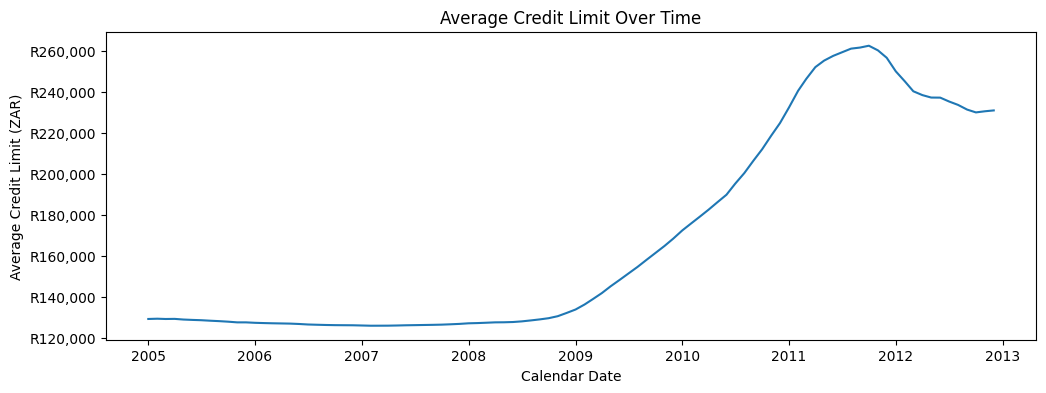

In [ ]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="AVG_CREDIT_LIMIT", errorbar=("ci", 50))
plt.title("Average Credit Limit Over Time")
plt.ylabel("Average Credit Limit (ZAR)")
plt.xlabel("Calendar Date")

ticks = plt.gca().get_yticks()
ylabels = ["R" + "{:,.0f}".format(y) for y in ticks]
plt.gca().set_yticklabels(ylabels)

plt.show()

### **Average Utilisation**

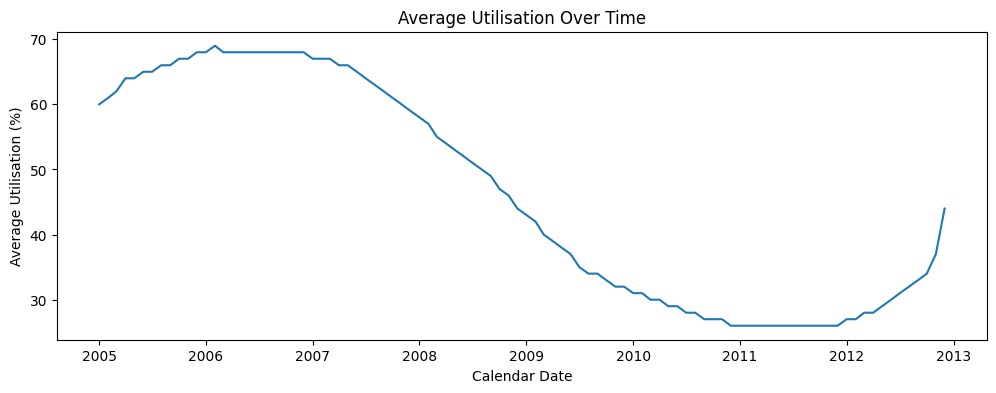

In [ ]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="AVG_UTILISATION", errorbar=("ci", 50))
plt.title("Average Utilisation Over Time")
plt.ylabel("Average Utilisation (%)")
plt.xlabel("Calendar Date")
plt.show()

### **Average 12M ODR**

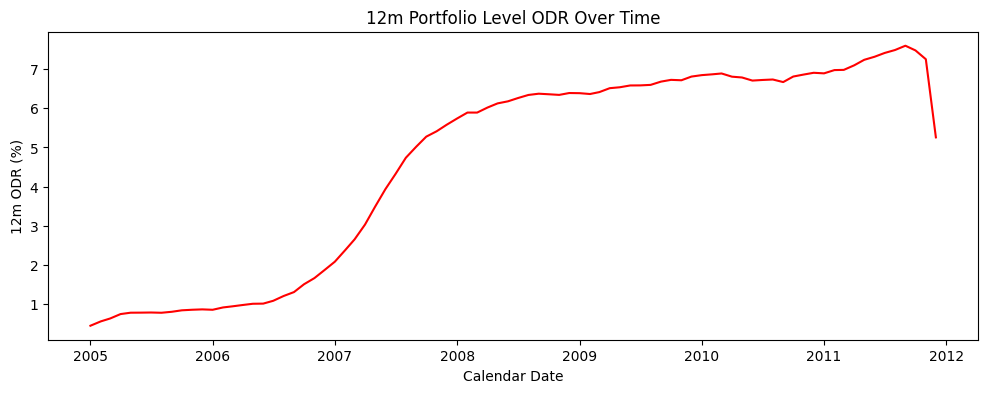

In [8]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df,
    x="CALENDAR_DATE",
    y="PORTFOLIO_LEVEL_12M_ODR",
    errorbar=("ci", 50),
    color="red",
)
plt.title("12m Portfolio Level ODR Over Time")
plt.ylabel("12m ODR (%)")
plt.xlabel("Calendar Date")

# Export plot to png
fig = plt.gcf()
fig.savefig("12m_portfolio_level_odr_over_time.png")

plt.show()

### **Inactive Rate**

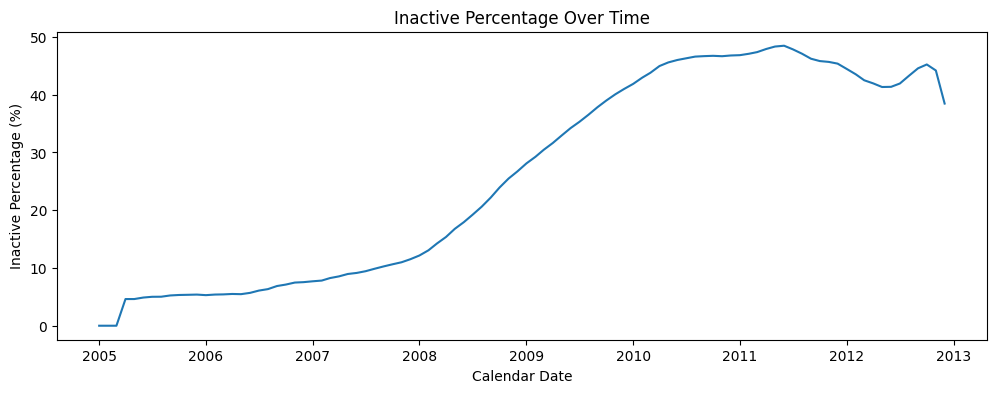

In [ ]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="INACTIVE_RATE", errorbar=("ci", 50))
plt.title("Inactive Percentage Over Time")
plt.ylabel("Inactive Percentage (%)")
plt.xlabel("Calendar Date")
plt.show()

### **Transactor Rate**

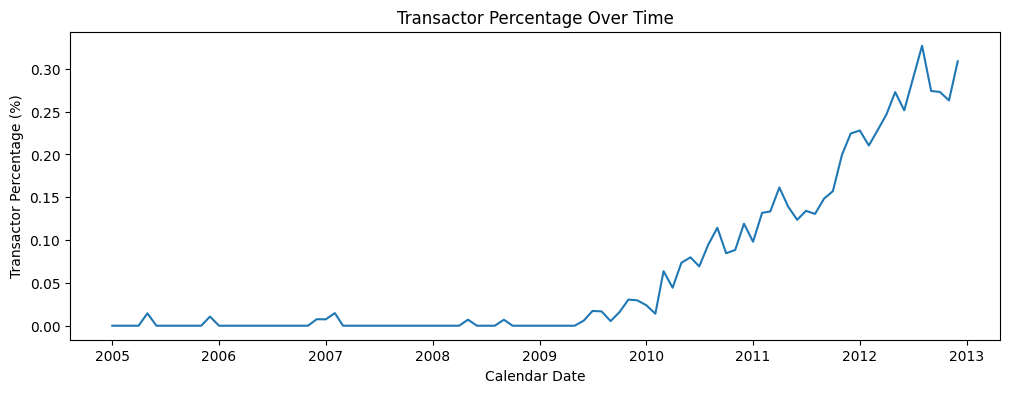

In [ ]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="TRANSACTOR_RATE", errorbar=("ci", 95))
plt.title("Transactor Percentage Over Time")
plt.ylabel("Transactor Percentage (%)")
plt.xlabel("Calendar Date")
plt.show()

## **Historical Key Metrics by Arrears Stage**

The figures below show the historical volume, balance and credit limit by the different arrears stages. 


In [48]:
query = f"""
    SELECT 
        ARREARS_STAGE,
        CALENDAR_DATE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        ROUND(SUM(AMT_BALANCE), 0) AS TOTAL_BALANCE,
        ROUND(AVG(AMT_CREDIT_LIMIT_ACTUAL), 0) AS AVG_CREDIT_LIMIT,
        ROUND(AVG(AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL), 2)*100 AS AVG_UTILISATION,
        SUM("12M_DEFAULT_OUTCOME")/COUNT(DISTINCT SK_ID_PREV)*100 AS "12M_ODR",
        SUM(TRANSACTOR_INDICATOR)/COUNT(DISTINCT SK_ID_PREV)*100 AS TRANSACTOR_RATE,
        SUM(INACTIVE_INDICATOR)/COUNT(DISTINCT SK_ID_PREV)*100 AS INACTIVE_RATE
    FROM '{INPUT_PATH_STR}'
    GROUP BY ARREARS_STAGE, CALENDAR_DATE
    ORDER BY ARREARS_STAGE, CALENDAR_DATE ASC;
"""
df = con.sql(query).df()

total_by_date = (
    df.groupby("CALENDAR_DATE")
    .agg(
        TOTAL_VOLUME=("TOTAL_VOLUME", "sum"),
        TOTAL_BALANCE=("TOTAL_BALANCE", "sum"),
    )
    .reset_index()
)

df_normalized = df.merge(total_by_date, on="CALENDAR_DATE", suffixes=("", "_TOTAL"))

for col in ["TOTAL_VOLUME", "TOTAL_BALANCE"]:
    df_normalized[col + "_NORM"] = (
        df_normalized[col] / df_normalized[col + "_TOTAL"] * 100
    )

### **Total Volume**

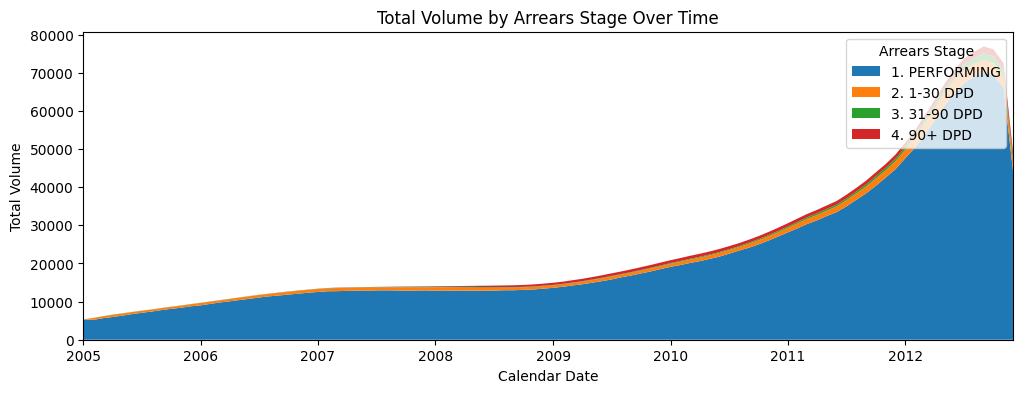

In [41]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_VOLUME"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Total Volume by Arrears Stage Over Time")
plt.ylabel("Total Volume")
plt.xlabel("Calendar Date")
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Total Volume %**

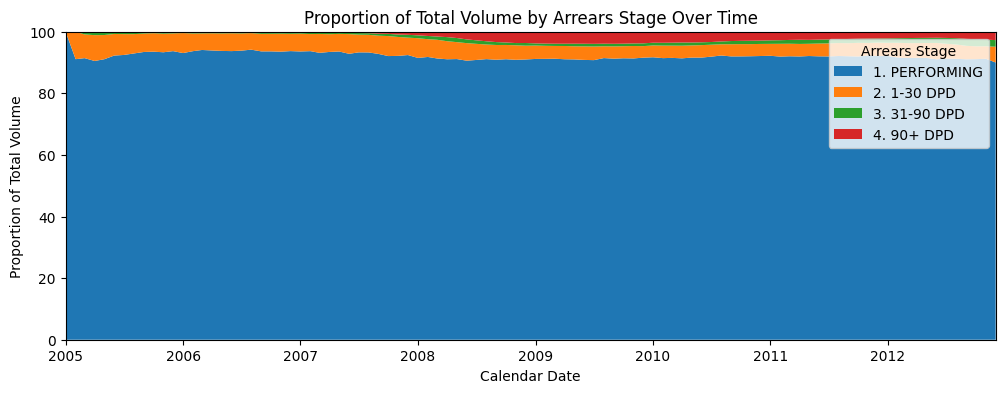

In [42]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_VOLUME_NORM"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Proportion of Total Volume by Arrears Stage Over Time")
plt.ylabel("Proportion of Total Volume")
plt.xlabel("Calendar Date")
plt.ylim(0, 100)
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Total Balance**

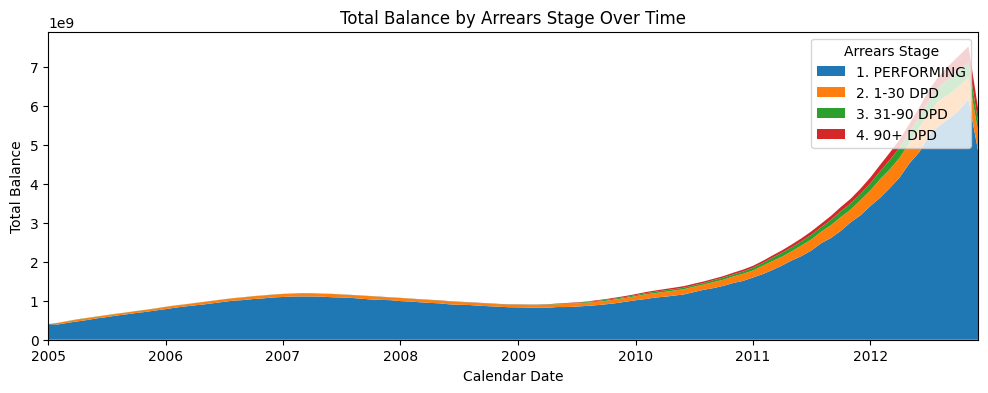

In [43]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_BALANCE"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Total Balance by Arrears Stage Over Time")
plt.ylabel("Total Balance")
plt.xlabel("Calendar Date")
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Total Balance %**

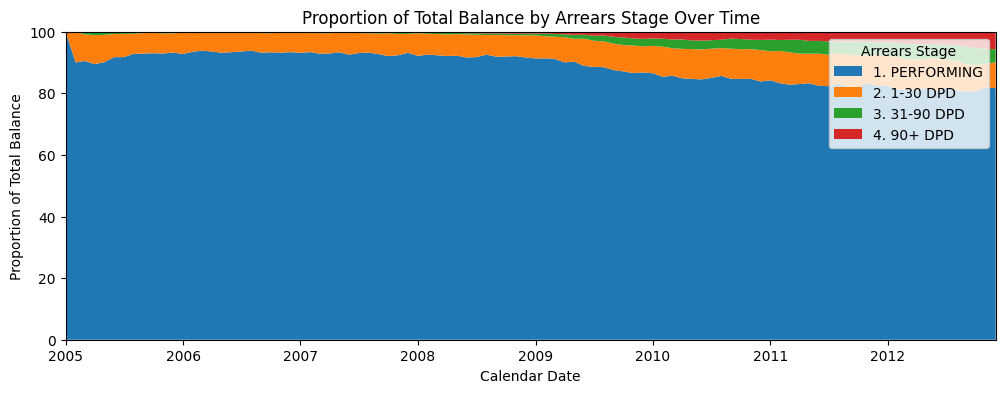

In [44]:
stacked_df = df_normalized.pivot(
    index="CALENDAR_DATE", columns="ARREARS_STAGE", values="TOTAL_BALANCE_NORM"
).fillna(0)

plt.figure(figsize=(12, 4))
plt.stackplot(stacked_df.index, stacked_df.T, labels=stacked_df.columns)
plt.title("Proportion of Total Balance by Arrears Stage Over Time")
plt.ylabel("Proportion of Total Balance")
plt.xlabel("Calendar Date")
plt.ylim(0, 100)
plt.xlim(stacked_df.index.min(), stacked_df.index.max())
plt.legend(title="Arrears Stage", loc="upper right")
plt.show()

### **Average Credit Limit**

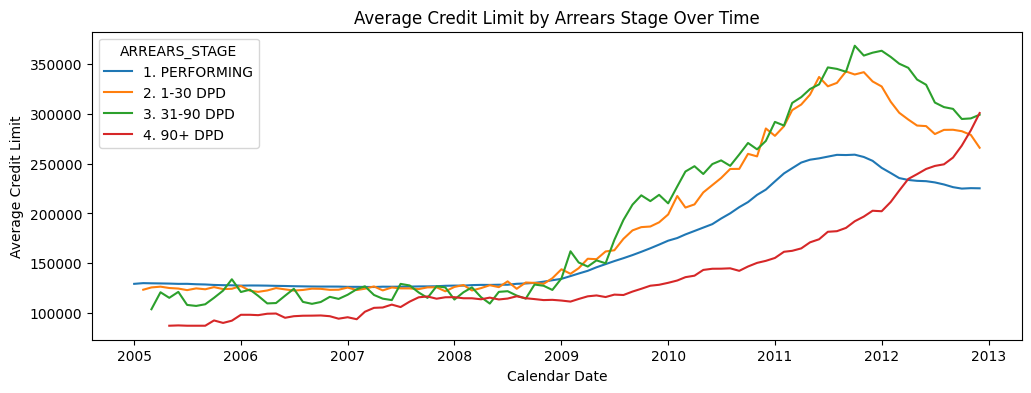

In [45]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="AVG_CREDIT_LIMIT", hue="ARREARS_STAGE"
)
plt.title("Average Credit Limit by Arrears Stage Over Time")
plt.ylabel("Average Credit Limit")
plt.xlabel("Calendar Date")
plt.show()

### **Average Utilisation**

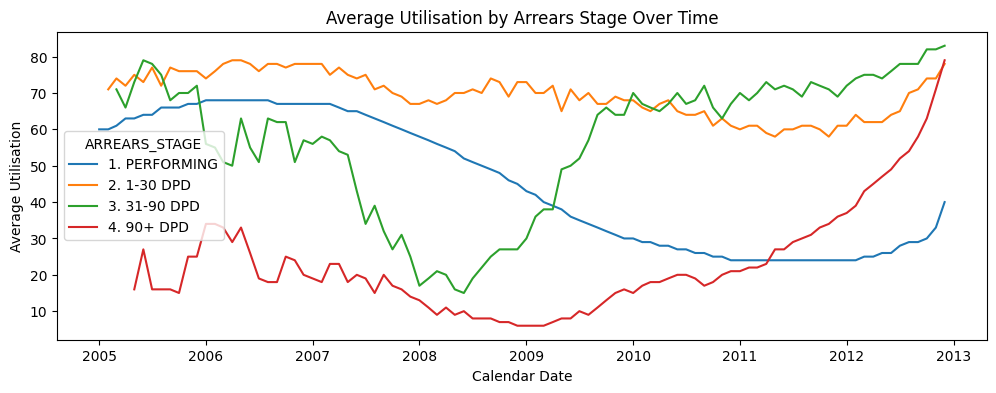

In [46]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="AVG_UTILISATION", hue="ARREARS_STAGE"
)
plt.title("Average Utilisation by Arrears Stage Over Time")
plt.ylabel("Average Utilisation")
plt.xlabel("Calendar Date")
plt.show()

### **Average 12M ODR**

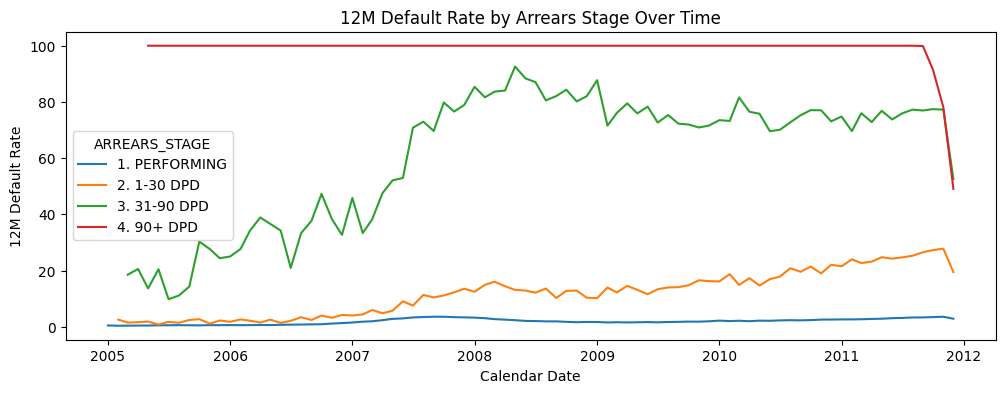

In [50]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_normalized, x="CALENDAR_DATE", y="12M_ODR", hue="ARREARS_STAGE")
plt.title("12M Default Rate by Arrears Stage Over Time")
plt.ylabel("12M Default Rate")
plt.xlabel("Calendar Date")
plt.show()

### **Inactive Rate**

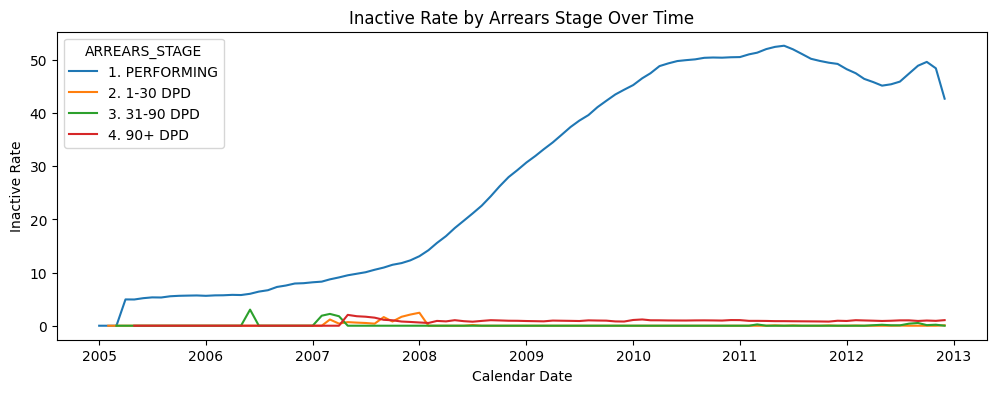

In [42]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="INACTIVE_RATE", hue="ARREARS_STAGE"
)
plt.title("Inactive Rate by Arrears Stage Over Time")
plt.ylabel("Inactive Rate")
plt.xlabel("Calendar Date")
plt.show()

### **Transactor Rate**

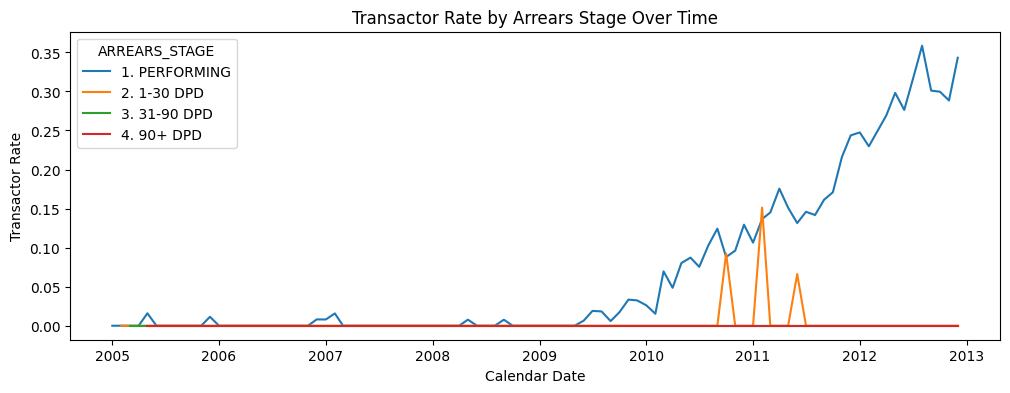

In [16]:
plt.figure(figsize=(12, 4))
sns.lineplot(
    data=df_normalized, x="CALENDAR_DATE", y="TRANSACTOR_RATE", hue="ARREARS_STAGE"
)
plt.title("Transactor Rate by Arrears Stage Over Time")
plt.ylabel("Transactor Rate")
plt.xlabel("Calendar Date")
plt.show()

## **Historical Default Rates**

### **Average 12M 90+ DPD ODR**

In [5]:
query = f"""
    SELECT 
        CALENDAR_DATE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        SUM("12M_90DPD_OUTCOME")/COUNT(DISTINCT SK_ID_PREV)*100 AS "90_DPD_12M_ODR",
    FROM '{INPUT_PATH_STR}'
    GROUP BY CALENDAR_DATE
    ORDER BY CALENDAR_DATE ASC;
"""

df = con.sql(query).df()

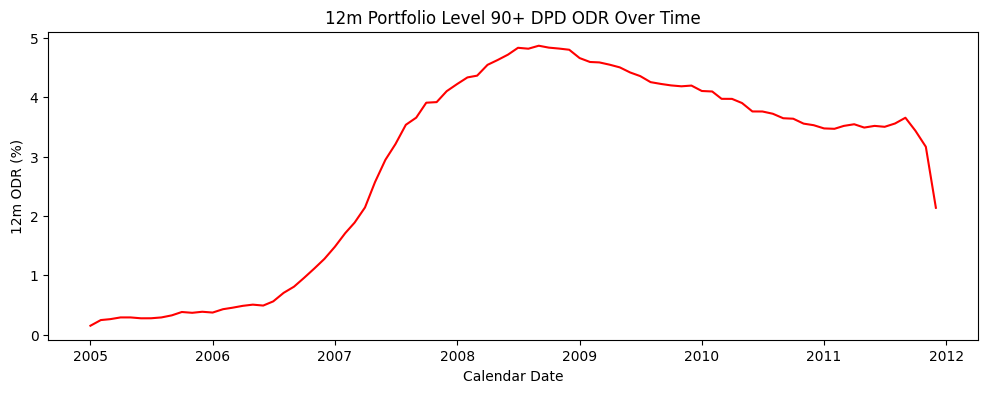

In [6]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="90_DPD_12M_ODR", color="red")
plt.title("12m Portfolio Level 90+ DPD ODR Over Time")
plt.ylabel("12m ODR (%)")
plt.xlabel("Calendar Date")

# Export plot to png
fig = plt.gcf()
os.chdir(r"C:\Users\mario\Documents\GitHub Repos\guides\docs\application\banks\credit_risk\02_airb_capital_modelling\01_introduction\images")
fig.savefig("12m_portfolio_level_90dpd_odr_over_time.png")

plt.show()

### **Average 12M 90+ DPD Re-default Rate**



In [18]:
query = f"""
    SELECT 
        CALENDAR_DATE,
        COUNT(DISTINCT SK_ID_PREV) AS TOTAL_VOLUME,
        SUM("12M_90DPD_OUTCOME")/COUNT(DISTINCT SK_ID_PREV)*100 AS "90_DPD_12M_RD",
    FROM '{INPUT_PATH_STR}'
    WHERE CURE_INDICATOR = TRUE
    GROUP BY CALENDAR_DATE
    ORDER BY CALENDAR_DATE ASC;
"""

df = con.sql(query).df()

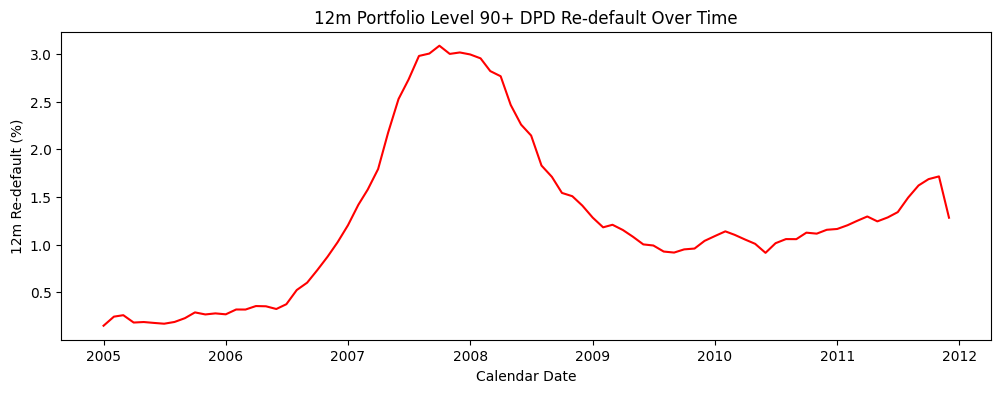

In [19]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df, x="CALENDAR_DATE", y="90_DPD_12M_RD", color="red")
plt.title("12m Portfolio Level 90+ DPD Re-default Over Time")
plt.ylabel("12m Re-default (%)")
plt.xlabel("Calendar Date")

# Export plot to png
fig = plt.gcf()
os.chdir(r"C:\Users\mario\Documents\GitHub Repos\guides\docs\application\banks\credit_risk\02_airb_capital_modelling\01_introduction\images")
fig.savefig("12m_portfolio_level_90dpd_redefault_over_time.png")

plt.show()

In [21]:
con.close()